# CRSP v2 Daily Basic EDA

This notebook performs basic exploratory data analysis on `crsp_v2_2014_2024.csv` with emphasis on univariate analysis.

Scope:
- Data loading and quick schema checks
- Missing values and duplicate diagnostics
- Univariate analysis for categorical, numeric, and date fields
- Basic sanity checks for OHLC and returns
- Export of summary tables for downstream modeling


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
print("Libraries loaded.")

Libraries loaded.


In [5]:
from pathlib import Path
import pandas as pd

# Project root finder
ROOT = Path.cwd()

# If notebook is running from notebooks/, move up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "crsp_v2_2014_2024.csv"
OUTPUT_DIR = ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Data path:", DATA_PATH)
print("Exists?", DATA_PATH.exists())
print("Output dir:", OUTPUT_DIR)

Project root: c:\Users\mkp22\OneDrive\Desktop\FA Project\FA-Project
Data path: c:\Users\mkp22\OneDrive\Desktop\FA Project\FA-Project\data\raw\crsp_v2_2014_2024.csv
Exists? True
Output dir: c:\Users\mkp22\OneDrive\Desktop\FA Project\FA-Project\data\processed


In [ ]:
# Config
DATA_PATH = Path("C:\\Users\\mkp22\\OneDrive\\Desktop\\FA Project\\FA-Project\\data\\raw\\crsp_v2_2014_2024.csv")
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set SAMPLE_N = None to use full data.
SAMPLE_N = 200000
RANDOM_SEED = 42

core_columns = [
    "permno", "permco", "ticker", "cusip", "issuernm", "siccd", "naics",
    "dlycaldt", "dlyclose", "dlyopen", "dlyhigh", "dlylow", "dlyprc",
    "dlyret", "dlyretx", "dlyvol", "shrout", "dlycap", "dlycumfacpr",
    "dlycumfacshr", "sprtrn", "vwretd", "ewretd", "securitytype",
    "sharetype", "usincflg", "shradrflg"
]

numeric_candidates = [
    "dlyclose", "dlyopen", "dlyhigh", "dlylow", "dlyprc", "dlyret", "dlyretx",
    "dlyvol", "shrout", "dlycap", "dlycumfacpr", "dlycumfacshr", "sprtrn",
    "vwretd", "ewretd"
]

categorical_candidates = ["securitytype", "sharetype", "usincflg", "shradrflg", "ticker"]

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Output path: {OUTPUT_DIR.resolve()}")

Data path: H:\My Drive\Project\FA Project\crsp_v2_2014_2024.csv
Output path: C:\Users\mkp22\OneDrive\Desktop\FA Project\FA-Project\notebooks\eda_outputs


In [16]:
# Load data
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

available_core_cols = [c for c in core_columns if c in df.columns]
missing_core_cols = [c for c in core_columns if c not in df.columns]

if "dlycaldt" in df.columns:
    df["dlycaldt"] = pd.to_datetime(df["dlycaldt"], errors="coerce")

for col in [c for c in numeric_candidates if c in df.columns]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# if SAMPLE_N is not None and SAMPLE_N < len(df):
#     df = df.sample(n=SAMPLE_N, random_state=RANDOM_SEED).sort_index().reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Available core columns: {len(available_core_cols)}")
if missing_core_cols:
    print("Missing expected core columns:", missing_core_cols)

df.head()

Rows: 495,987
Columns: 27
Available core columns: 27


,permno,permco,ticker,cusip,issuernm,siccd,naics,dlycaldt,dlyclose,dlyopen,dlyhigh,dlylow,dlyprc,dlyret,dlyretx,dlyvol,shrout,dlycap,dlycumfacpr,dlycumfacshr,sprtrn,vwretd,ewretd,securitytype,sharetype,usincflg,shradrflg
0,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-02,37.84,37.78,38.03,37.550,37.84,-0.010978,-0.010978,18163700.0,4497409,1.701820e+08,1.0,1.0,-0.008862,-0.008757,-0.004051,EQTY,NS,Y,N
1,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-03,37.62,37.65,37.86,37.560,37.62,-0.002643,-0.005814,11693900.0,4497409,1.691925e+08,1.0,1.0,-0.000333,0.000491,0.004096,EQTY,NS,Y,N
2,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-06,37.47,37.64,37.80,37.415,37.47,-0.003987,-0.003987,15330000.0,4497409,1.685179e+08,1.0,1.0,-0.002512,-0.003340,-0.001676,EQTY,NS,Y,N
3,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-07,37.85,37.66,37.93,37.500,37.85,0.010141,0.010141,16793300.0,4497409,1.702269e+08,1.0,1.0,0.006082,0.006090,0.006892,EQTY,NS,Y,N
4,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-08,37.72,37.79,37.91,37.560,37.72,-0.003435,-0.003435,16111600.0,4497409,1.696423e+08,1.0,1.0,-0.000212,0.000155,0.000835,EQTY,NS,Y,N


In [17]:
# Overview and quality diagnostics
schema_df = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True])

display(schema_df.head(30))

full_dup_count = int(df.duplicated().sum())
if {"permno", "dlycaldt"}.issubset(df.columns):
    key_dup_count = int(df.duplicated(subset=["permno", "dlycaldt"]).sum())
else:
    key_dup_count = np.nan

print(f"Full-row duplicates: {full_dup_count:,}")
print(f"permno+dlycaldt duplicates: {key_dup_count}")

schema_df.to_csv(OUTPUT_DIR / "schema_missingness_summary.csv", index=False)

,column,dtype,missing_count,missing_pct,n_unique
8,dlyclose,float64,277,0.06,63745
9,dlyopen,float64,277,0.06,64679
11,dlylow,float64,277,0.06,102406
10,dlyhigh,float64,277,0.06,102668
23,securitytype,str,0,0.00,1
24,sharetype,str,0,0.00,1
25,usincflg,str,0,0.00,1
26,shradrflg,str,0,0.00,1
19,dlycumfacshr,float64,0,0.00,16
18,dlycumfacpr,float64,0,0.00,44


Full-row duplicates: 16
permno+dlycaldt duplicates: 16


,securitytype,count,pct
0,EQTY,495987,100.0


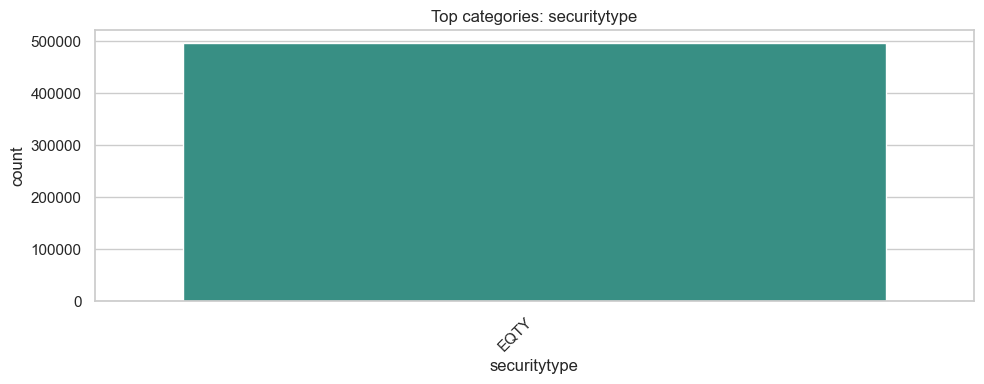

,sharetype,count,pct
0,NS,495987,100.0


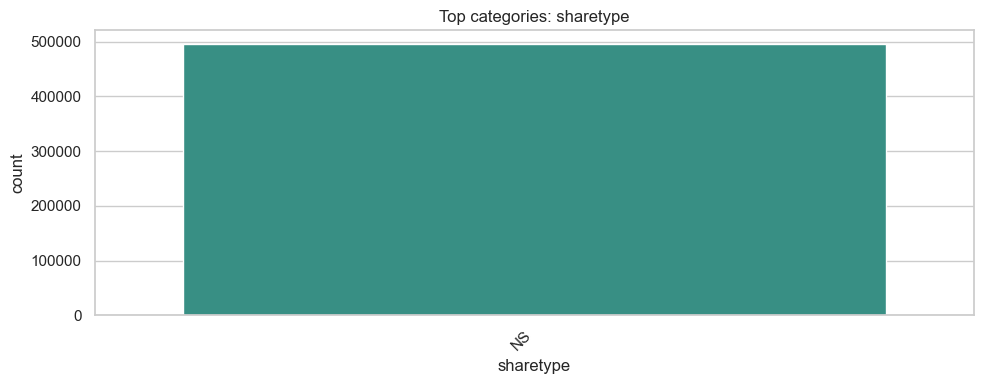

,usincflg,count,pct
0,Y,495987,100.0


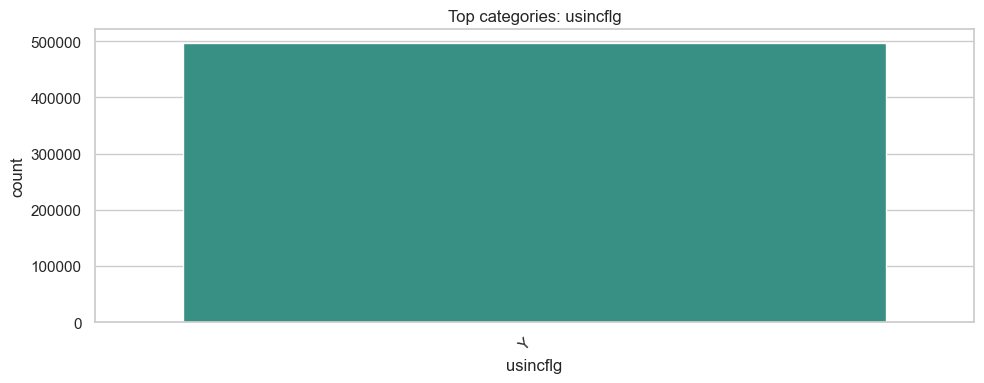

,shradrflg,count,pct
0,N,495987,100.0


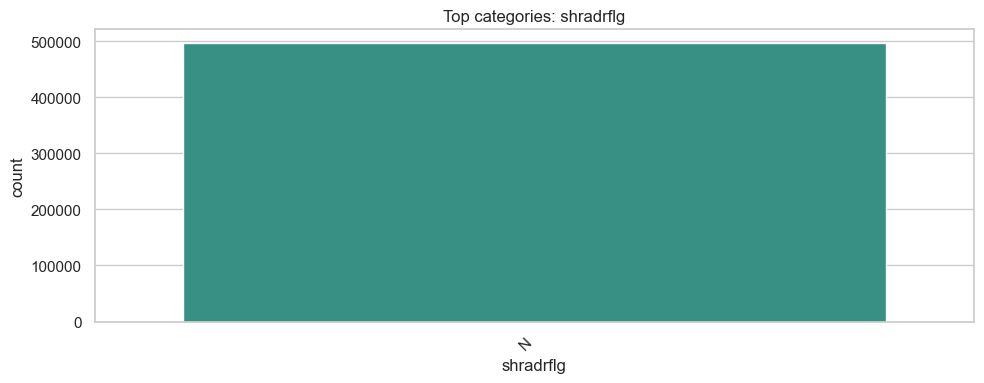

,ticker,count,pct
0,MKC,5536,1.12
1,F,2773,0.56
2,BBY,2770,0.56
3,CTAS,2769,0.56
4,EOG,2769,0.56
5,ORCL,2768,0.56
6,MSFT,2768,0.56
7,TROW,2768,0.56
8,ADM,2768,0.56
9,KO,2768,0.56


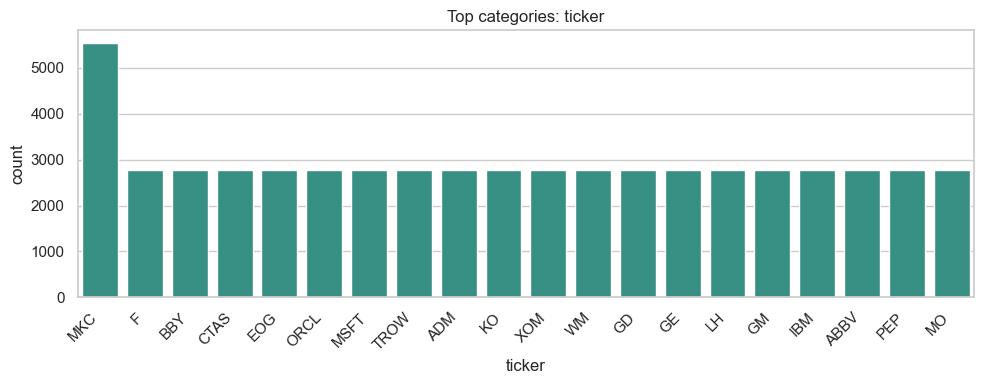

Categorical summary exported.


In [18]:
# Categorical univariate analysis
existing_cats = [c for c in categorical_candidates if c in df.columns]
cat_freq_tables = {}

for col in existing_cats:
    top_n = 20 if col == "ticker" else 10
    freq = (
        df[col]
        .fillna("<NA>")
        .astype(str)
        .value_counts(dropna=False)
        .head(top_n)
        .rename_axis(col)
        .reset_index(name="count")
    )
    freq["pct"] = (freq["count"] / len(df) * 100).round(2)
    cat_freq_tables[col] = freq
    display(freq)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=freq, x=col, y="count", color="#2A9D8F")
    plt.title(f"Top categories: {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if cat_freq_tables:
    cat_export = pd.concat(
        [v.assign(variable=k) for k, v in cat_freq_tables.items()],
        ignore_index=True
    )
    cat_export.to_csv(OUTPUT_DIR / "categorical_univariate_summary.csv", index=False)
    print("Categorical summary exported.")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_count,missing_pct
dlyclose,495710.0,1.601598e+02,2.813365e+02,2.100000,1.222000e+01,2.432000e+01,5.504000e+01,9.162000e+01,1.614575e+02,4.665955e+02,1.584326e+03,5.300340e+03,277,0.06
dlyopen,495710.0,1.601440e+02,2.813241e+02,2.200000,1.223000e+01,2.430000e+01,5.502000e+01,9.160000e+01,1.614500e+02,4.665910e+02,1.583609e+03,5.300000e+03,277,0.06
dlyhigh,495710.0,1.617922e+02,2.843553e+02,2.600000,1.240000e+01,2.460000e+01,5.556000e+01,9.250000e+01,1.630200e+02,4.715255e+02,1.598971e+03,5.337240e+03,277,0.06
dlylow,495710.0,1.584577e+02,2.782022e+02,1.930000,1.206000e+01,2.400000e+01,5.450000e+01,9.068000e+01,1.598600e+02,4.615000e+02,1.564992e+03,5.260000e+03,277,0.06
dlyprc,495986.0,1.601263e+02,2.812630e+02,2.100000,1.222000e+01,2.433000e+01,5.505000e+01,9.162000e+01,1.614200e+02,4.664175e+02,1.583995e+03,5.300340e+03,1,0.00
dlyret,495984.0,5.988227e-04,1.823264e-02,-0.538647,-4.926100e-02,-2.575985e-02,-7.398000e-03,7.570000e-04,8.801000e-03,2.591670e-02,4.967668e-02,6.464650e-01,3,0.00
dlyretx,495984.0,5.085932e-04,1.825545e-02,-0.538647,-4.943017e-02,-2.591400e-02,-7.513000e-03,6.800000e-04,8.735000e-03,2.585185e-02,4.960219e-02,6.464650e-01,3,0.00
dlyvol,495986.0,6.450505e+06,1.308824e+07,0.000000,1.708975e+05,4.565002e+05,1.292174e+06,2.667740e+06,6.254771e+06,2.457039e+07,6.026766e+07,6.575423e+08,1,0.00
shrout,495987.0,1.057452e+06,1.747422e+06,9064.000000,2.382700e+04,9.143800e+04,2.361450e+05,4.574510e+05,9.941270e+05,4.297435e+06,8.698115e+06,2.456884e+07,0,0.00
dlycap,495986.0,1.019673e+08,2.234875e+08,38249.400000,3.944609e+06,9.853094e+06,2.185659e+07,4.445710e+07,1.012785e+08,3.253289e+08,9.508571e+08,3.915300e+09,1,0.00


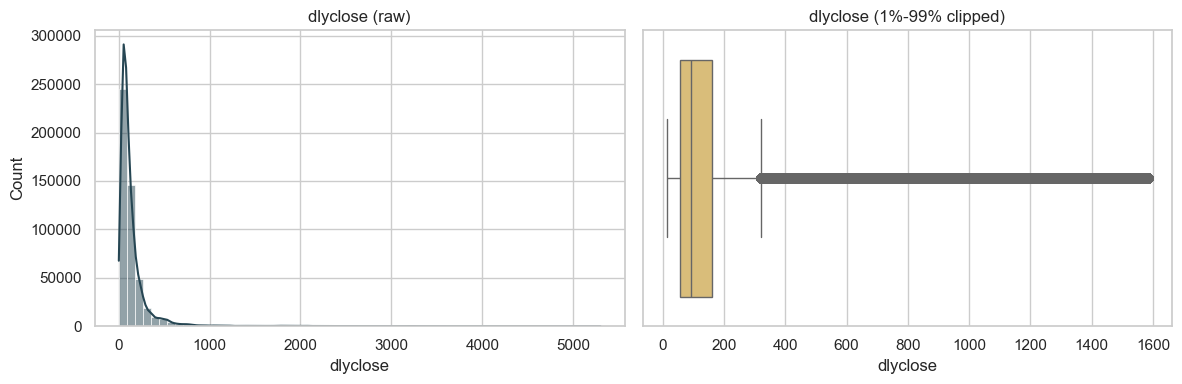

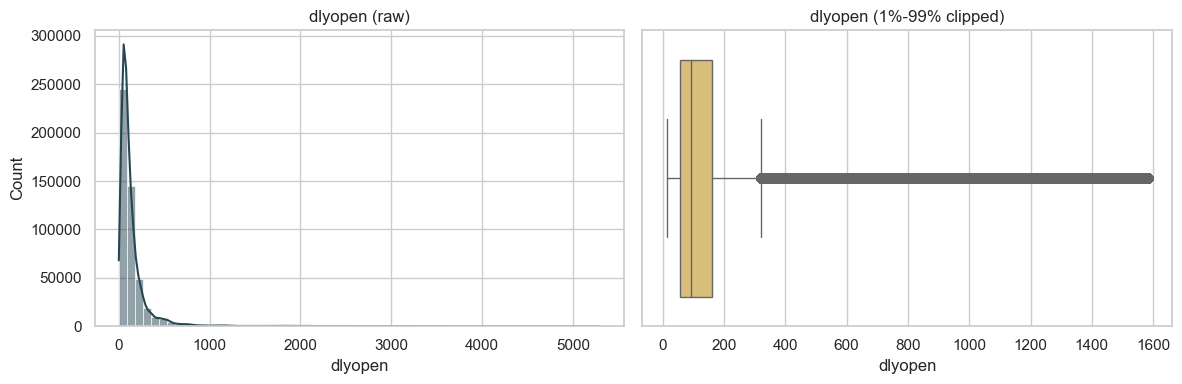

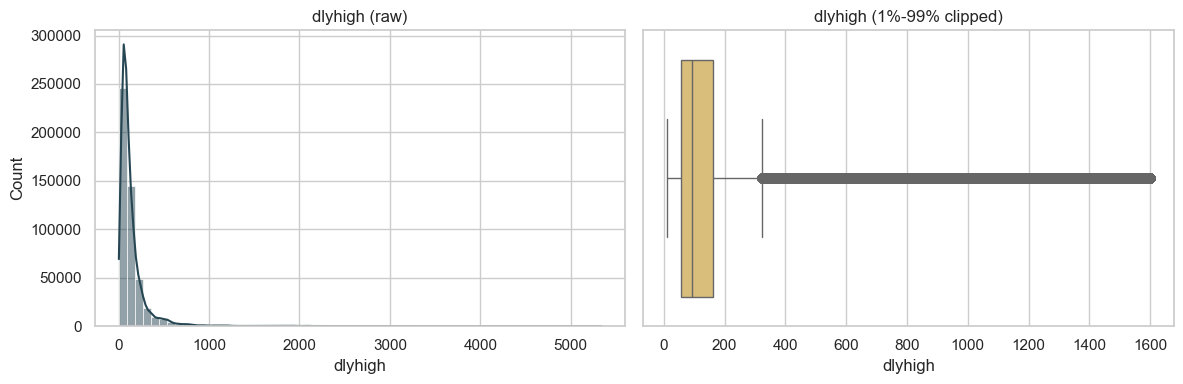

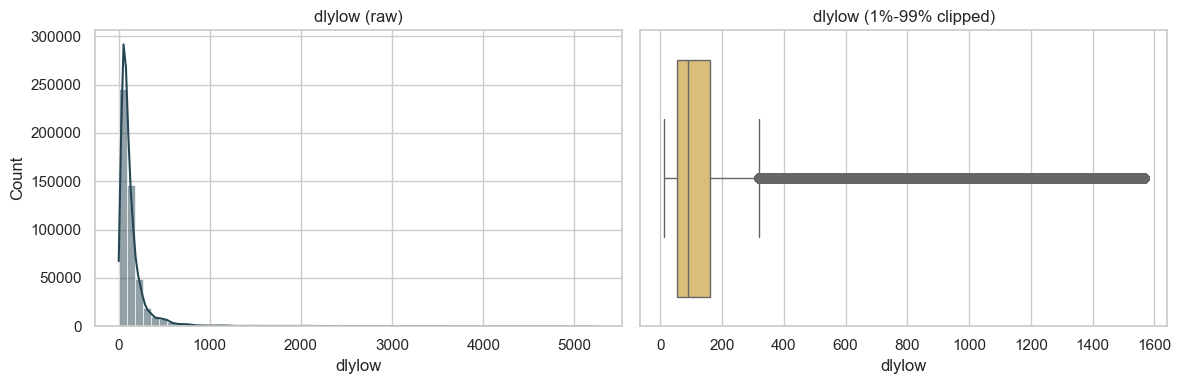

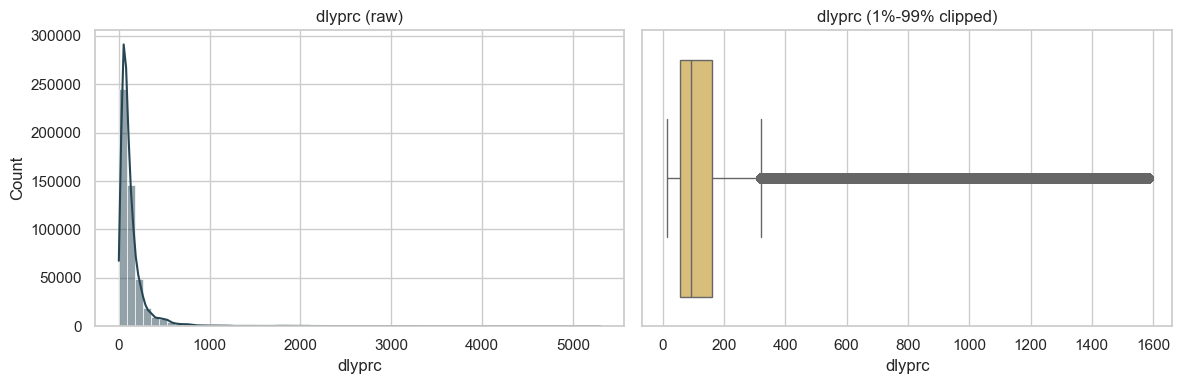

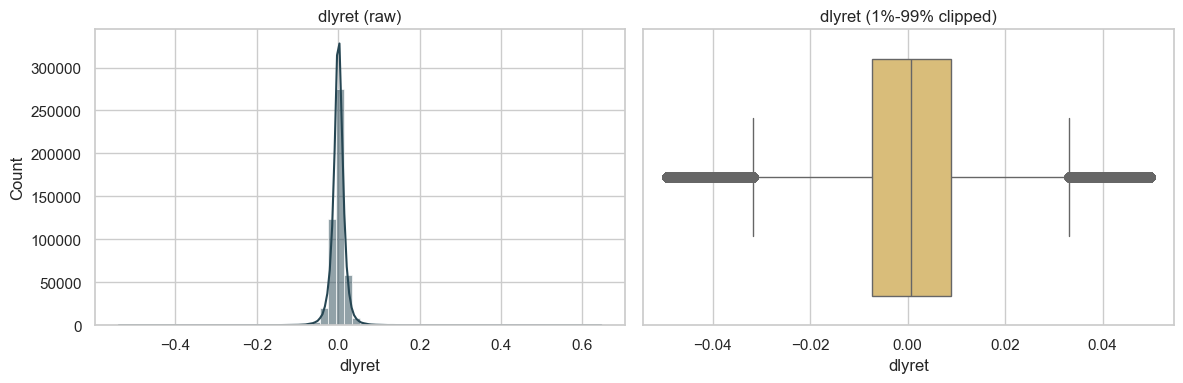

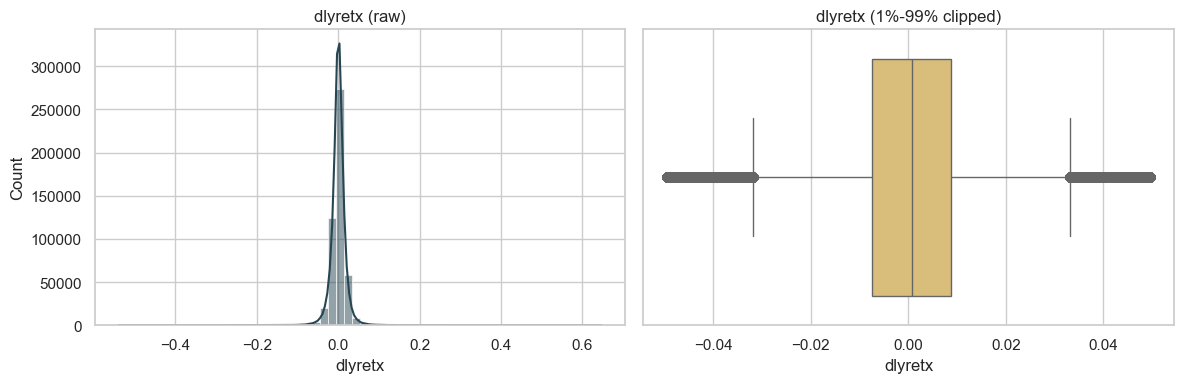

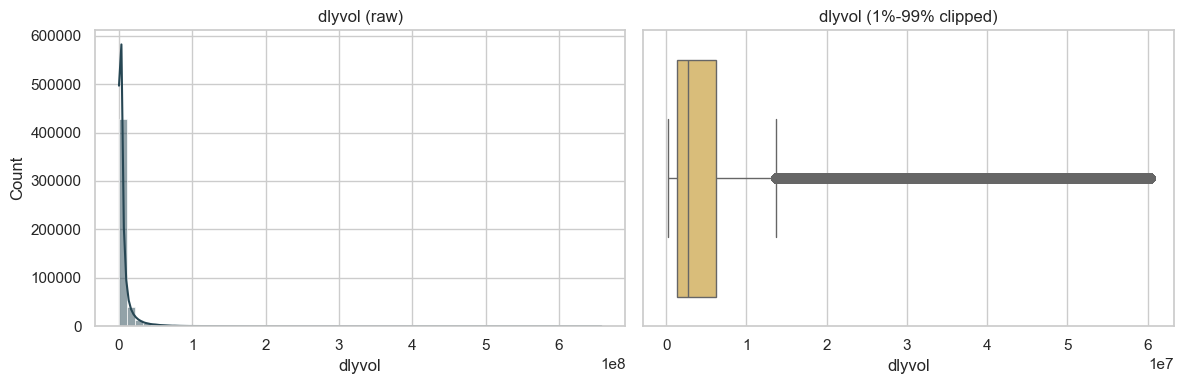

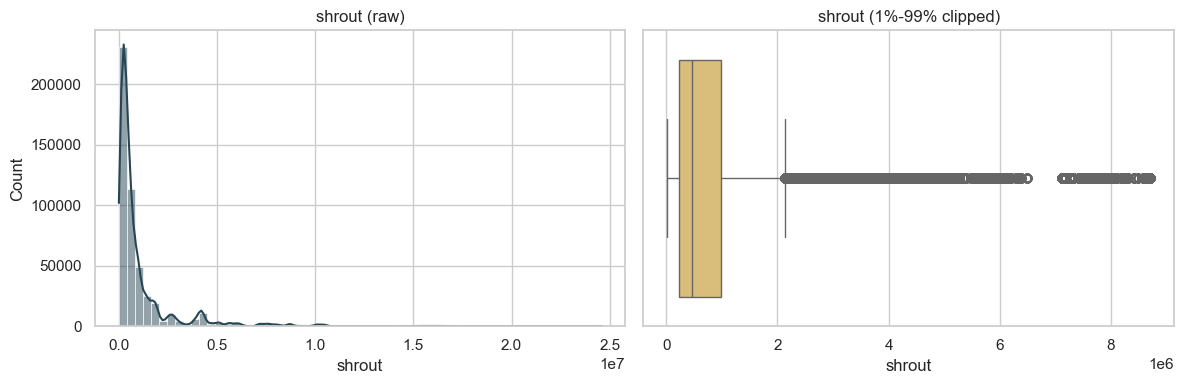

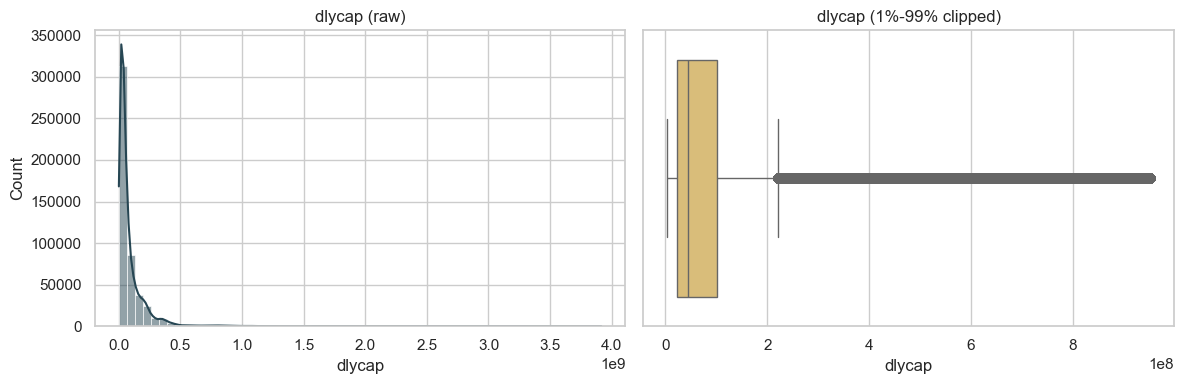

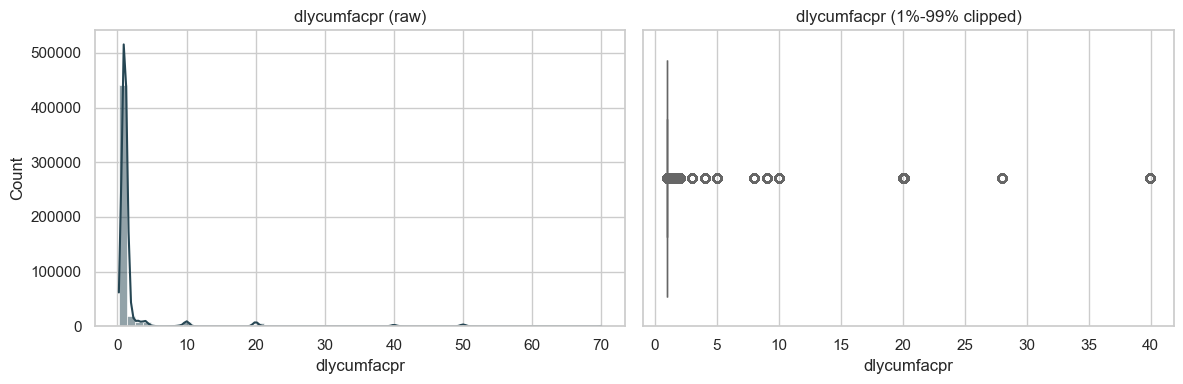

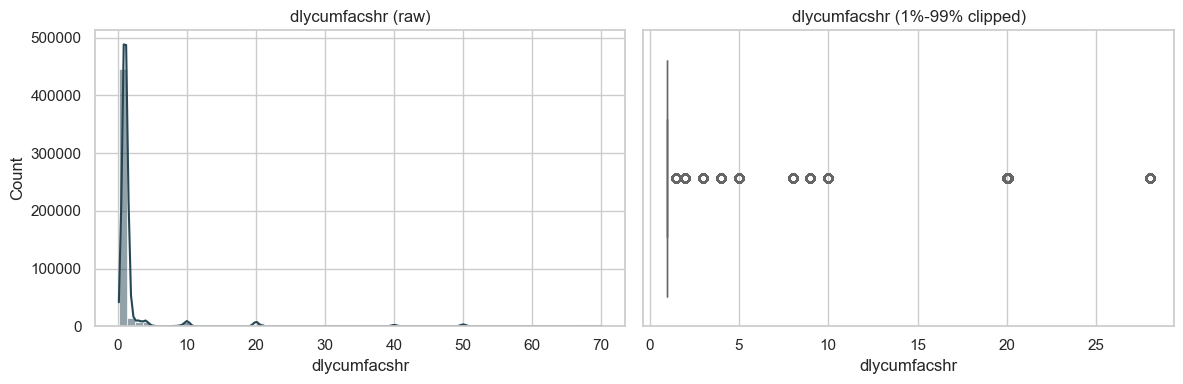

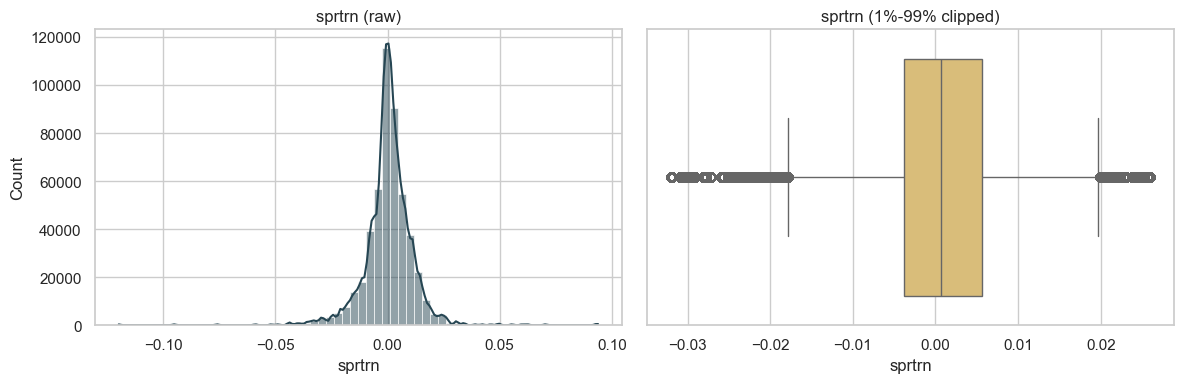

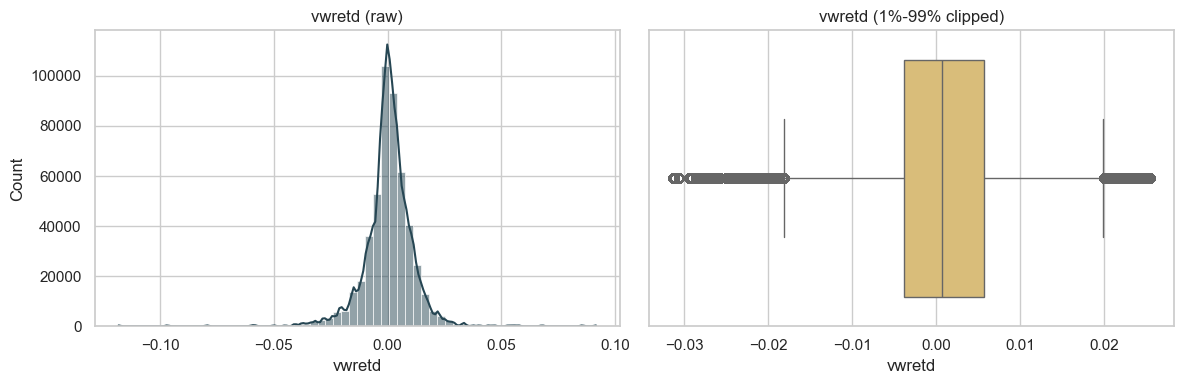

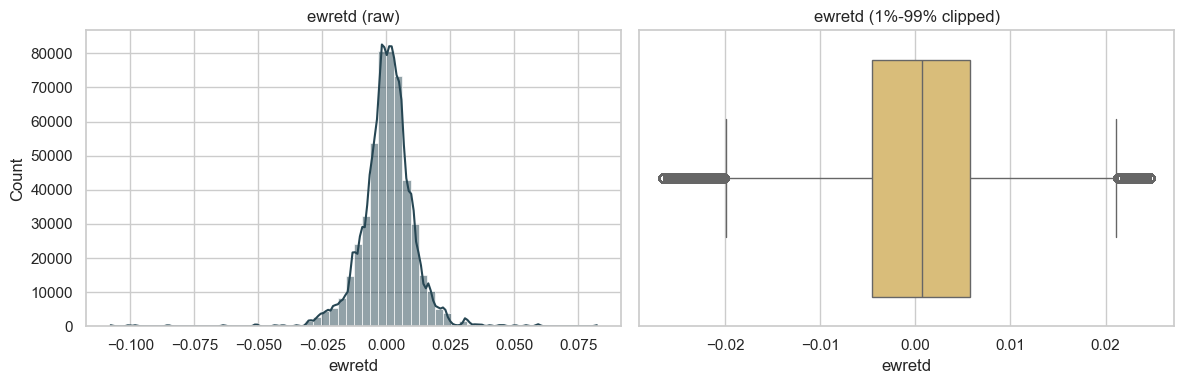

In [19]:
# Numeric univariate analysis
num_cols = [c for c in numeric_candidates if c in df.columns]

if num_cols:
    desc = df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    desc["missing_count"] = df[num_cols].isna().sum()
    desc["missing_pct"] = (df[num_cols].isna().mean() * 100).round(2)
    display(desc)
    desc.to_csv(OUTPUT_DIR / "numeric_univariate_summary.csv")

    for col in num_cols:
        series = df[col].dropna()
        if series.empty:
            continue

        p1, p99 = series.quantile([0.01, 0.99])
        clipped = series.clip(lower=p1, upper=p99)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(series, bins=60, kde=True, ax=axes[0], color="#264653")
        axes[0].set_title(f"{col} (raw)")

        sns.boxplot(x=clipped, ax=axes[1], color="#E9C46A")
        axes[1].set_title(f"{col} (1%-99% clipped)")

        plt.tight_layout()
        plt.show()
else:
    print("No numeric columns from the candidate list were found.")

Date range: 2014-01-02 00:00:00 to 2024-12-31 00:00:00
Missing dlycaldt rows: 0


,year,row_count
0,2014,44786
1,2015,44499
2,2016,44535
3,2017,44428
4,2018,44862
5,2019,45360
6,2020,45731
7,2021,45443
8,2022,45326
9,2023,45194


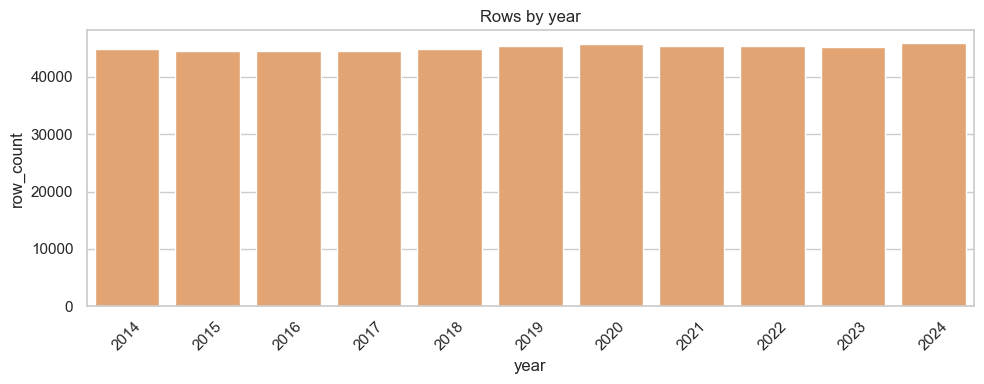

In [20]:
# Date univariate analysis
if "dlycaldt" in df.columns:
    min_dt = df["dlycaldt"].min()
    max_dt = df["dlycaldt"].max()
    missing_dt = int(df["dlycaldt"].isna().sum())

    print(f"Date range: {min_dt} to {max_dt}")
    print(f"Missing dlycaldt rows: {missing_dt:,}")

    by_year = (
        df.dropna(subset=["dlycaldt"])
        .assign(year=lambda x: x["dlycaldt"].dt.year)
        .groupby("year", as_index=False)
        .size()
        .rename(columns={"size": "row_count"})
    )
    display(by_year)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=by_year, x="year", y="row_count", color="#F4A261")
    plt.title("Rows by year")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    by_year.to_csv(OUTPUT_DIR / "date_univariate_year_counts.csv", index=False)
else:
    print("dlycaldt not available.")

In [21]:
# Basic sanity checks
checks = {}

if {"dlylow", "dlyhigh", "dlyopen", "dlyclose"}.issubset(df.columns):
    valid_ohlc = (
        (df["dlylow"] <= df["dlyopen"]) &
        (df["dlyopen"] <= df["dlyhigh"]) &
        (df["dlylow"] <= df["dlyclose"]) &
        (df["dlyclose"] <= df["dlyhigh"])
    )
    checks["ohlc_invalid_count"] = int((~valid_ohlc).sum())

if "dlyret" in df.columns:
    checks["dlyret_abs_gt_30pct_count"] = int((df["dlyret"].abs() > 0.30).sum())
    checks["dlyret_abs_gt_100pct_count"] = int((df["dlyret"].abs() > 1.00).sum())

if "dlyretx" in df.columns:
    checks["dlyretx_abs_gt_30pct_count"] = int((df["dlyretx"].abs() > 0.30).sum())
    checks["dlyretx_abs_gt_100pct_count"] = int((df["dlyretx"].abs() > 1.00).sum())

checks_df = pd.DataFrame(list(checks.items()), columns=["check", "value"])
display(checks_df)
checks_df.to_csv(OUTPUT_DIR / "basic_sanity_checks.csv", index=False)

print("Saved outputs:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)

,check,value
0,ohlc_invalid_count,277
1,dlyret_abs_gt_30pct_count,16
2,dlyret_abs_gt_100pct_count,0
3,dlyretx_abs_gt_30pct_count,16
4,dlyretx_abs_gt_100pct_count,0


Saved outputs:
- basic_sanity_checks.csv
- categorical_univariate_summary.csv
- date_univariate_year_counts.csv
- numeric_univariate_summary.csv
- schema_missingness_summary.csv


Final Cleaned CRSP Output

In [4]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/crsp_v2_2014_2024.csv")
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)

# Keep only useful columns for modeling/dashboard
keep_cols = [
    "permno", "permco", "ticker", "cusip", "issuernm", "siccd", "naics",
    "dlycaldt", "dlyclose", "dlyopen", "dlyhigh", "dlylow", "dlyprc",
    "dlyret", "dlyretx", "dlyvol", "shrout", "dlycap",
    "sprtrn", "vwretd", "ewretd"
]

keep_cols = [c for c in keep_cols if c in df.columns]
clean_crsp = df[keep_cols].copy()

# Clean ticker/date
clean_crsp["ticker"] = clean_crsp["ticker"].astype(str).str.strip().str.upper()
clean_crsp["date"] = pd.to_datetime(clean_crsp["dlycaldt"], errors="coerce")

# Drop bad rows
clean_crsp = clean_crsp.dropna(subset=["ticker", "date"])

# Remove duplicates
clean_crsp = clean_crsp.drop_duplicates(subset=["ticker", "date"])

# Sort
clean_crsp = clean_crsp.sort_values(["ticker", "date"]).reset_index(drop=True)

# Optional: remove original date column if not needed
clean_crsp = clean_crsp.drop(columns=["dlycaldt"], errors="ignore")

# Save
clean_crsp.to_parquet(OUTPUT_DIR / "clean_crsp.parquet", index=False)

print(clean_crsp.shape)
clean_crsp.head()

(493203, 21)


,permno,permco,ticker,cusip,issuernm,siccd,naics,dlyclose,dlyopen,dlyhigh,dlylow,dlyprc,dlyret,dlyretx,dlyvol,shrout,dlycap,sprtrn,vwretd,ewretd,date
0,87432,36364,A,00846U10,AGILENT TECHNOLOGIES INC,3825,334515,56.21,57.10,57.100,56.15,56.21,-0.017136,-0.017136,1916200.0,331809,18650983.89,-0.008862,-0.008757,-0.004051,2014-01-02
1,87432,36364,A,00846U10,AGILENT TECHNOLOGIES INC,3825,334515,56.92,56.39,57.345,56.26,56.92,0.012631,0.012631,1866700.0,331809,18886568.28,-0.000333,0.000491,0.004096,2014-01-03
2,87432,36364,A,00846U10,AGILENT TECHNOLOGIES INC,3825,334515,56.64,57.40,57.700,56.56,56.64,-0.004919,-0.004919,1777500.0,331809,18793661.76,-0.002512,-0.003340,-0.001676,2014-01-06
3,87432,36364,A,00846U10,AGILENT TECHNOLOGIES INC,3825,334515,57.45,56.95,57.630,56.93,57.45,0.014301,0.014301,1463200.0,331809,19062427.05,0.006082,0.006090,0.006892,2014-01-07
4,87432,36364,A,00846U10,AGILENT TECHNOLOGIES INC,3825,334515,58.39,57.33,58.540,57.17,58.39,0.016362,0.016362,2659500.0,331809,19374327.51,-0.000212,0.000155,0.000835,2014-01-08


## Interpretation Notes (Fill After Run)

Use this section to summarize:
- Which variables are most skewed or heavy-tailed
- Which flags dominate the universe (e.g., EQTY/NS/Y/N)
- Whether missingness is concentrated in specific fields
- Whether basic sanity checks show data quality concerns
- Which columns look most ready for feature engineering
